In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

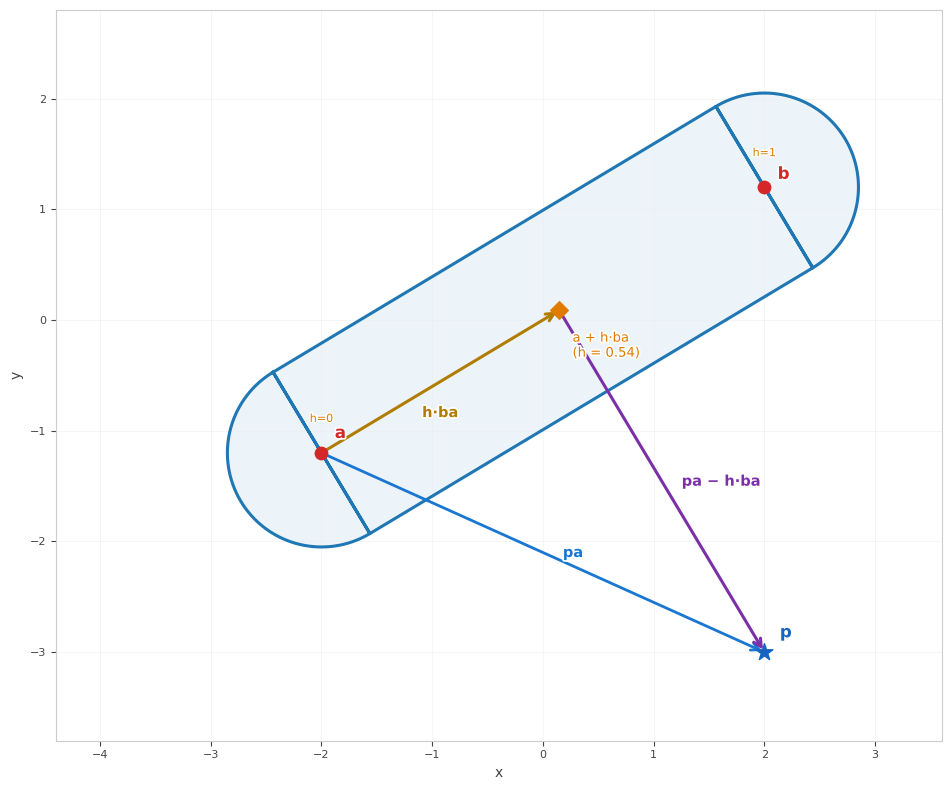

h = 0.537, closest = [0.14705882 0.08823529]


In [2]:
# ─── Palette ──────────────────────────────────────────────────────────────────
BG        = 'white'
CAPSULE   = '#1f77b4'
AXIS_CLR  = '#d62728'
PROJ_CLR  = '#e07b00'
QUERY_CLR = '#1565c0'
PA_CLR    = '#1976d2'
BA_CLR    = '#b07d00'
PERP_CLR  = '#7b2fa8'
DIM_CLR   = '#444444'

# ─── Capsule definition ───────────────────────────────────────────────────────
A = np.array([-2.0, -1.2])
B = np.array([ 2.0,  1.2])
R = 0.85

# Query point
P = np.array([2.0, -3.0])

# ─── SDF computation ─────────────────────────────────────────────────────────
pa = P - A
ba = B - A
h  = np.clip(np.dot(pa, ba) / np.dot(ba, ba), 0.0, 1.0)
closest      = A + h * ba
vec_to_p     = P - closest
dist_closest = np.linalg.norm(vec_to_p)
dir_to_p     = vec_to_p / dist_closest

# ─── Build capsule outline ────────────────────────────────────────────────────
def capsule_outline(a, b, r, res=400):
    axis      = b - a
    n         = axis / np.linalg.norm(axis)
    angle_deg = np.degrees(np.arctan2(n[1], n[0]))
    perp      = np.array([-n[1], n[0]])

    side1_a = a + perp * r
    side1_b = b + perp * r
    side2_b = b - perp * r
    side2_a = a - perp * r

    t_b = np.linspace(angle_deg - 90, angle_deg + 90, res // 2)
    sem_b_x = b[0] + r * np.cos(np.radians(t_b))
    sem_b_y = b[1] + r * np.sin(np.radians(t_b))

    t_a = np.linspace(angle_deg + 90, angle_deg + 270, res // 2)
    sem_a_x = a[0] + r * np.cos(np.radians(t_a))
    sem_a_y = a[1] + r * np.sin(np.radians(t_a))

    xs = ([side1_a[0], side1_b[0]]
          + list(sem_b_x)
          + [side2_b[0], side2_a[0]]
          + list(sem_a_x)
          + [side1_a[0]])
    ys = ([side1_a[1], side1_b[1]]
          + list(sem_b_y)
          + [side2_b[1], side2_a[1]]
          + list(sem_a_y)
          + [side1_a[1]])
    return np.array(xs), np.array(ys)

cap_x, cap_y = capsule_outline(A, B, R)

# ─── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8), facecolor=BG)
ax.set_facecolor(BG)
ax.set_aspect('equal')
ax.set_xlim(-4.4, 3.6)
ax.set_ylim(-3.8, 2.8)

for sp in ax.spines.values():
    sp.set_color('#cccccc')
ax.tick_params(colors=DIM_CLR, labelsize=8)
ax.grid(True, color='#eeeeee', linewidth=0.5, alpha=0.8, zorder=0)

# ── Capsule ───────────────────────────────────────────────────────────────────
ax.fill(cap_x, cap_y, color=CAPSULE, alpha=0.08, zorder=1)
ax.plot(cap_x, cap_y, color=CAPSULE, lw=2.2, alpha=1.0, zorder=2)

# ── Endpoints ─────────────────────────────────────────────────────────────────
ax.scatter(*A, color=AXIS_CLR, s=80, zorder=10)
ax.scatter(*B, color=AXIS_CLR, s=80, zorder=10)

# ── pa vector: a → p ──────────────────────────────────────────────────────────
ax.annotate('', xy=P, xytext=A,
            arrowprops=dict(arrowstyle='->', color=PA_CLR, lw=2.0,
                            mutation_scale=14))

# ── h·ba vector: a → closest ─────────────────────────────────────────────────
ax.annotate('', xy=closest, xytext=A,
            arrowprops=dict(arrowstyle='->', color=BA_CLR, lw=2.2,
                            mutation_scale=14))

# ── (pa − h·ba) vector: closest → p ──────────────────────────────────────────
ax.annotate('', xy=P, xytext=closest,
            arrowprops=dict(arrowstyle='->', color=PERP_CLR, lw=2.2,
                            mutation_scale=14))

# ── Closest point ─────────────────────────────────────────────────────────────
ax.scatter(*closest, color=PROJ_CLR, s=80, zorder=12, marker='D')

# ── Query point ───────────────────────────────────────────────────────────────
ax.scatter(*P, color=QUERY_CLR, s=160, zorder=12, marker='*')

# ── Labels ────────────────────────────────────────────────────────────────────
def lbl(pos, txt, color, dx=0.08, dy=0.08, fs=10.5, fw='bold', ha='left'):
    ax.text(pos[0]+dx, pos[1]+dy, txt, color=color, fontsize=fs,
            fontweight=fw, ha=ha, va='center',
            path_effects=[pe.withStroke(linewidth=2.5, foreground=BG)])

lbl(A, 'a', AXIS_CLR,  dx= 0.12, dy= 0.18, fs=12)
lbl(B, 'b', AXIS_CLR,  dx= 0.12, dy= 0.12, fs=12)
lbl(P, 'p', QUERY_CLR, dx=0.14, dy=0.18, fs=12)

lbl(closest, f'a + h·ba\n(h = {h:.2f})', PROJ_CLR,
    dx=0.12, dy=-0.32, fs=9.5, fw='normal')

pa_mid = A + pa * 0.5
lbl(pa_mid, 'pa', PA_CLR, dx=0.18, dy=0.0, fs=10.5, ha='left')

hba_mid = A + h * ba * 0.5
lbl(hba_mid, 'h·ba', BA_CLR, dx=0.0, dy=-0.28, fs=10.5, ha='center')

perp_mid = closest + vec_to_p * 0.5
lbl(perp_mid, 'pa − h·ba', PERP_CLR, dx=0.18, dy=0.0, fs=10.5, ha='left')

ax.text(A[0], A[1]+0.28, 'h=0', color=PROJ_CLR, fontsize=8,
        ha='center', path_effects=[pe.withStroke(linewidth=2, foreground=BG)])
ax.text(B[0], B[1]+0.28, 'h=1', color=PROJ_CLR, fontsize=8,
        ha='center', path_effects=[pe.withStroke(linewidth=2, foreground=BG)])

ax.set_xlabel('x', color=DIM_CLR)
ax.set_ylabel('y', color=DIM_CLR)

plt.tight_layout()
plt.show()
print(f"h = {h:.3f}, closest = {closest}")

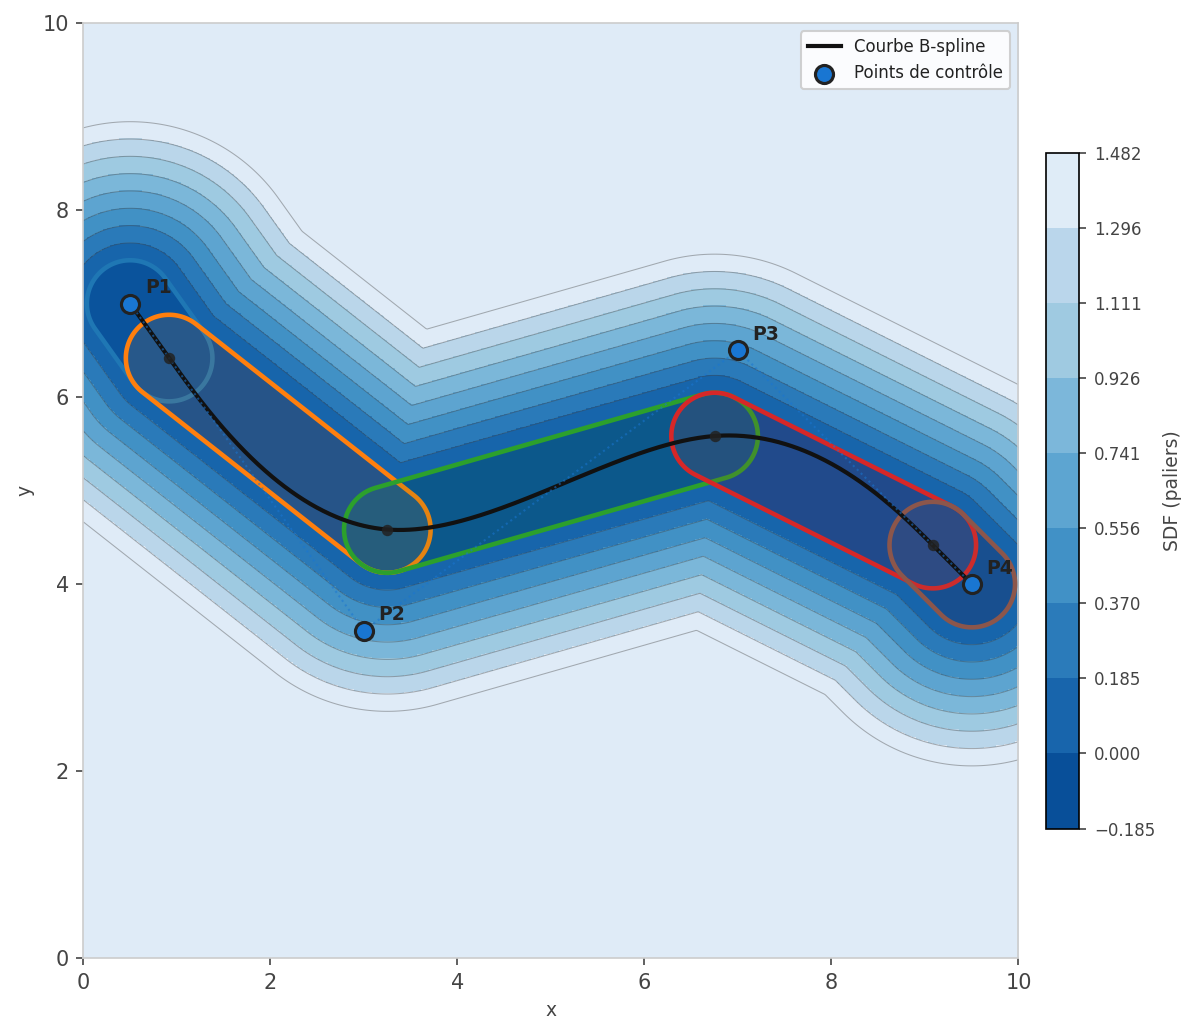

done


In [3]:
def bspline_pos(p0, p1, p2, p3, t):
    t2, t3 = t*t, t*t*t
    b0 = (-t3 + 3*t2 - 3*t + 1) / 6.0
    b1 = ( 3*t3 - 6*t2      + 4) / 6.0
    b2 = (-3*t3 + 3*t2 + 3*t + 1) / 6.0
    b3 =   t3                      / 6.0
    return p0*b0 + p1*b1 + p2*b2 + p3*b3

P = np.array([[0.5, 7.0],
              [3.0, 3.5],
              [7.0, 6.5],
              [9.5, 4.0]])

# B-spline bridée : répéter les extrémités 3× pour forcer le passage par P[0] et P[-1]
clamped = np.array([P[0], P[0], P[0], P[1], P[2], P[3], P[3], P[3]])
n_segs  = len(clamped) - 3  # 5 segments

def eval_clamped(pts, t_global):
    """t_global ∈ [0, n_segs]"""
    i   = int(np.clip(t_global, 0, n_segs - 1))
    t   = t_global - i
    return bspline_pos(pts[i], pts[i+1], pts[i+2], pts[i+3], t)

T_fine = np.linspace(0, n_segs, 800)
curve  = np.array([eval_clamped(clamped, t) for t in T_fine])

N_CAPS = 5
T_caps = np.linspace(0, n_segs, N_CAPS + 1)
caps   = np.array([eval_clamped(clamped, t) for t in T_caps])

seg_lengths = np.linalg.norm(np.diff(caps, axis=0), axis=1)
RADIUS = float(np.mean(seg_lengths) * 0.22)

# --- SDF ----------------------------------------------------------------
RES = 700
x1d = np.linspace(0, 10, RES)
y1d = np.linspace(0, 10, RES)
XX, YY = np.meshgrid(x1d, y1d)
pts = np.stack([XX.ravel(), YY.ravel()], axis=1)

def capsule_sdf_batch(q, A, B):
    AB   = B - A
    len2 = float(np.dot(AB, AB))
    if len2 < 1e-12:
        return np.linalg.norm(q - A, axis=1)
    t       = np.clip(((q - A) @ AB) / len2, 0.0, 1.0)
    closest = A + t[:, None] * AB
    return np.linalg.norm(q - closest, axis=1)

dist = np.full(len(pts), np.inf)
for i in range(N_CAPS):
    dist = np.minimum(dist, capsule_sdf_batch(pts, caps[i], caps[i+1]))

sdf_img = (dist - RADIUS).reshape(RES, RES)

STEP      = RADIUS * 0.4
MAX_BANDS = 8
levels    = np.arange(-1, MAX_BANDS + 1) * STEP
n_colors  = MAX_BANDS + 2
blues     = plt.cm.Blues(np.linspace(0.88, 0.12, n_colors))
cmap      = plt.cm.colors.ListedColormap(blues)
norm      = BoundaryNorm(levels, ncolors=n_colors, clip=True)

def capsule_patch(A, B, r, n_arc=60, **kwargs):
    AB   = B - A
    tang = AB / np.linalg.norm(AB)
    perp = np.array([-tang[1], tang[0]])
    angles_B = np.linspace(-np.pi/2,  np.pi/2,  n_arc)
    angles_A = np.linspace( np.pi/2,  3*np.pi/2, n_arc)
    arc_B = B + r * (np.outer(np.cos(angles_B), tang) +
                     np.outer(np.sin(angles_B), perp))
    arc_A = A + r * (np.outer(np.cos(angles_A), tang) +
                     np.outer(np.sin(angles_A), perp))
    verts = np.vstack([arc_B, arc_A, arc_B[0:1]])
    codes = ([Path.MOVETO] +
             [Path.LINETO] * (len(arc_B) - 1) +
             [Path.LINETO] * len(arc_A) +
             [Path.CLOSEPOLY])
    return PathPatch(Path(verts, codes), **kwargs)

# --- plot ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.imshow(sdf_img, origin='lower', extent=[0, 10, 0, 10],
          cmap=cmap, norm=norm, interpolation='nearest', zorder=0)

visible = levels[levels >= -STEP * 0.4]
ax.contour(XX, YY, sdf_img, levels=visible,
           colors='#444444', linewidths=0.5, alpha=0.4, zorder=1)

cap_colors = plt.cm.tab10(np.linspace(0, 0.5, N_CAPS))
for i in range(N_CAPS):
    ax.add_patch(capsule_patch(caps[i], caps[i+1], RADIUS,
                               facecolor=(*cap_colors[i][:3], 0.12),
                               edgecolor=(*cap_colors[i][:3], 1.0),
                               linewidth=2.2, linestyle='-', zorder=3))

ax.scatter(caps[:, 0], caps[:, 1],
           s=30, color='#222222', zorder=5, linewidths=0, alpha=0.85)

ax.plot(curve[:, 0], curve[:, 1],
        color='#111111', lw=2.0, zorder=4, label='Courbe B-spline')

ax.plot(P[:, 0], P[:, 1],
        color='#1976d2', lw=1.0, linestyle=':', alpha=0.55, zorder=4)

ax.scatter(P[:, 0], P[:, 1],
           s=75, color='#1976d2', edgecolors='#222222',
           linewidths=1.5, zorder=7, label='Points de contrôle')
for i, p in enumerate(P):
    ax.annotate(f'P{i+1}', p, xytext=(7, 5), textcoords='offset points',
                fontsize=9, color='#222222', fontweight='bold', zorder=8)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('SDF (paliers)', fontsize=9, color='#444')
cbar.ax.yaxis.set_tick_params(color='#444', labelcolor='#444', labelsize=8)

ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.set_xlabel('x', fontsize=9, color='#444')
ax.set_ylabel('y', fontsize=9, color='#444')
ax.tick_params(colors='#444')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.legend(fontsize=8, loc='upper right',
          framealpha=0.9, facecolor='white', edgecolor='#cccccc', labelcolor='#222222')

plt.tight_layout()
plt.show()
print("done")